In [7]:
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense,Flatten,Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report,confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
from  tensorflow.keras.callbacks import Callback


## Preprocessing the dataset

In [13]:
# Preprocessing the Training set
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)
training_set = train_datagen.flow_from_directory('Train',
                                                 target_size = (224,224),
                                                 batch_size = 32,
                                                 color_mode = 'rgb',
                                                 class_mode = 'categorical')

# Preprocessing the Test set
test_datagen = ImageDataGenerator(rescale = 1./255)
test_set = test_datagen.flow_from_directory('test',
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            color_mode = 'rgb',
                                            class_mode = 'categorical')
# validation set
validation_datagen = ImageDataGenerator(rescale = 1./255)
validation_set = validation_datagen.flow_from_directory('validation',
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            color_mode = 'rgb',
                                            class_mode = 'categorical')

Found 13483 images belonging to 27 classes.
Found 1346 images belonging to 27 classes.
Found 1346 images belonging to 27 classes.


## Creating and  Applying the model

In [14]:
import random 
import numpy as  np
seed = 42 
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [15]:
tf.device("cpu")

In [16]:
class StopAtAccuracy(Callback):
    def __init__(self, target=0.95):
        super().__init__()
        self.target = target

    def on_epoch_end(self, epoch, logs=None):
        acc = logs.get('val_accuracy')
        if acc is not None:
            if acc >= self.target:
                print(f"\nReached {self.target*100}% val_accuracy, stopping training!")
                self.model.stop_training = True

In [18]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3),classes=27)
base_model.trainable = False  # freeze conv layers

model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dense(27, activation='softmax')
])

model.compile(optimizer=Adam(0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
# Fitting the model
r= model.fit(training_set,epochs=5,validation_data=validation_set,callbacks=[StopAtAccuracy(target=0.95)])

c:\Users\zakaria\anaconda3\envs\tensorflow\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/5
244/422 ━━━━━━━━━━━━━━━━━━━━ 14:05 5s/step - accuracy: 0.3477 - loss: 2.6222

c:\Users\zakaria\anaconda3\envs\tensorflow\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 2. 
  warnings.warn(str(msg))


422/422 ━━━━━━━━━━━━━━━━━━━━ 2265s 5s/step - accuracy: 0.5810 - loss: 1.5108 - val_accuracy: 0.8492 - val_loss: 0.5688
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2571s 6s/step - accuracy: 0.8015 - loss: 0.6874 - val_accuracy: 0.8975 - val_loss: 0.3622
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3098s 7s/step - accuracy: 0.8637 - loss: 0.4638 - val_accuracy: 0.9250 - val_loss: 0.2412
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9022 - loss: 0.3341
Reached 95.0% val_accuracy, stopping training!
422/422 ━━━━━━━━━━━━━━━━━━━━ 2318s 5s/step - accuracy: 0.8978 - loss: 0.3438 - val_accuracy: 0.9517 - val_loss: 0.1671


In [19]:
# evaluating the model
model.evaluate(test_set)

c:\Users\zakaria\anaconda3\envs\tensorflow\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


18/43 ━━━━━━━━━━━━━━━━━━━━ 2:08 5s/step - accuracy: 0.9489 - loss: 0.1727

c:\Users\zakaria\anaconda3\envs\tensorflow\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 2. 
  warnings.warn(str(msg))


43/43 ━━━━━━━━━━━━━━━━━━━━ 208s 5s/step - accuracy: 0.9517 - loss: 0.1671


[0.1671072244644165, 0.9517087936401367]

In [21]:
print(training_set.class_indices)

{'Apple': 0, 'Banana': 1, 'Broccoli': 2, 'Carrots': 3, 'Cauliflower': 4, 'Chili': 5, 'Coconut': 6, 'Cucumber': 7, 'Custard apple': 8, 'Dates': 9, 'Garlic': 10, 'Grape': 11, 'Green Lemon': 12, 'Jackfruit': 13, 'Kiwi': 14, 'Mango': 15, 'Okra': 16, 'Onion': 17, 'Orange': 18, 'Papaya': 19, 'Peanut': 20, 'Pineapple': 21, 'Pomegranate': 22, 'Star Fruit': 23, 'Strawberry': 24, 'Sweet Potato': 25, 'Watermelon': 26}


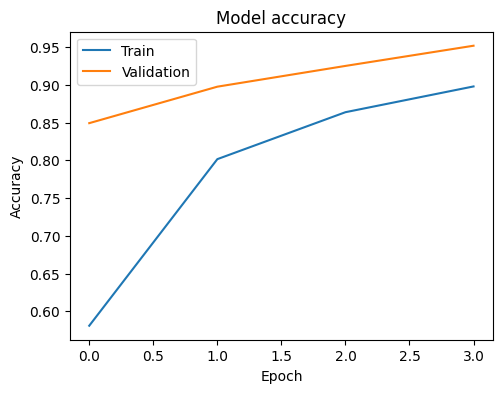

In [22]:
import matplotlib.pyplot as plt
# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(r.history['accuracy'])
plt.plot(r.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

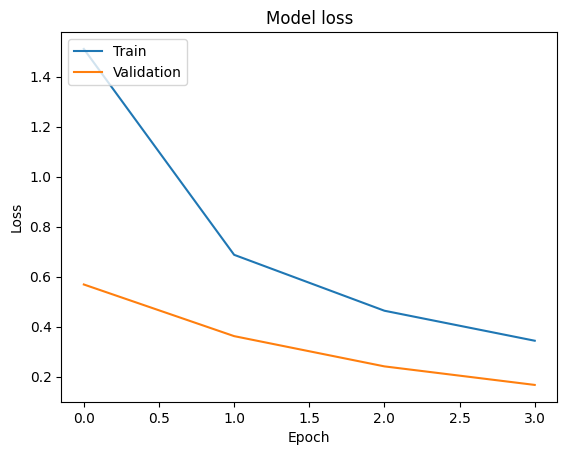

In [23]:
plt.plot(r.history['loss'])
plt.plot(r.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

In [24]:
predictions = model.predict(test_set)

13/43 ━━━━━━━━━━━━━━━━━━━━ 2:18 5s/step

c:\Users\zakaria\anaconda3\envs\tensorflow\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


17/43 ━━━━━━━━━━━━━━━━━━━━ 2:00 5s/step

c:\Users\zakaria\anaconda3\envs\tensorflow\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 2. 
  warnings.warn(str(msg))


43/43 ━━━━━━━━━━━━━━━━━━━━ 195s 5s/step


In [25]:
for classes in np.argmax(predictions[:5], axis=1):
    for num_label, label in training_set.class_indices.items():
        if classes == label:
            print(f"{classes}:{num_label}")

9:Dates
26:Watermelon
20:Peanut
7:Cucumber
7:Cucumber


In [ ]:
def load_image_for_prediction(image_path, target_size=(224, 224)):
    # Read & decode image
    img = tf.io.read_file(image_path)
    img = tf.io.decode_jpeg(img, channels=3)
    # Resize
    img = tf.image.resize(img, target_size)
    # Normalize
    img = tf.cast(img, tf.float32) / 255.0
    # Add batch dimension
    img = tf.expand_dims(img, axis=0)
    return img

In [27]:
image = load_image_for_prediction(image_path="apple.jpg",target_size=(224,224))

In [28]:
prediction = model.predict(image)
predicted_class = np.argmax(prediction, axis=1)[0]
for num_label, label in training_set.class_indices.items():
    if predicted_class == label:
        print(f"{predicted_class}: {num_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
0: Apple


In [29]:
np.max(predicted_class)

np.int64(0)

In [32]:
image_1 = load_image_for_prediction(image_path="20260224_160225.jpg",target_size=(224,224))

In [33]:
prediction = model.predict(image_1)
predicted_class = np.argmax(prediction, axis=1)[0]
for num_label, label in training_set.class_indices.items():
    if predicted_class == label:
        print(f"{predicted_class}: {num_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
18: Orange


In [35]:
image_2 = load_image_for_prediction(image_path="20260224_160228.jpg",target_size=(224,224))

In [36]:
prediction = model.predict(image_2)
predicted_class = np.argmax(prediction, axis=1)[0]
for num_label, label in training_set.class_indices.items():
    if predicted_class == label:
        print(f"{predicted_class}: {num_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
0: Apple


In [37]:
image_3 = load_image_for_prediction(image_path="20260224_160231.jpg",target_size=(224,224))

In [38]:
prediction = model.predict(image_3)
predicted_class = np.argmax(prediction, axis=1)[0]
for num_label, label in training_set.class_indices.items():
    if predicted_class == label:
        print(f"{predicted_class}: {num_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1: Banana


In [39]:
image_4 = load_image_for_prediction(image_path="watermelon.jpg",target_size=(224,224))

In [40]:
prediction = model.predict(image_4)
predicted_class = np.argmax(prediction, axis=1)[0]
for num_label, label in training_set.class_indices.items():
    if predicted_class == label:
        print(f"{predicted_class}: {num_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
26: Watermelon


In [41]:
# Save as .h5
model.save("fruit_vegetable_model.h5")